# Notebook 04fb— MS training  (4 Bands: MS Red + MS Green + NIR + Red-edge)

This notebook is the MS-only version of the SegFormer training pipeline.
The RGB notebook (04a_RGB_Training.ipynb) remains untouched.

| ID | Class |
|----|-------|
| 0  | Maize |
| 1  | Maize+Pumpkin |
| 2  | Beans+Maize |
| 3  | Cassava+Maize (low-confidence) |
| 4  | Grass |
| 5  | Mixed |
| 255 | Background (ignored) |

## 0. Configuration

In [1]:
from pathlib import Path

MODALITY = 'ms'

BASE_DIR   = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
TILES_DIR  = BASE_DIR / "Tiles"
OUTPUT_DIR = BASE_DIR / "Models" / MODALITY
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_DIR = TILES_DIR / MODALITY / "images"
LBL_DIR = TILES_DIR / "labels"

IN_CHANNELS  = 4       # MS Red, MS Green, NIR, Red-edge
NUM_CLASSES  = 6
IGNORE_INDEX = 255
BACKBONE     = 'nvidia/mit-b0'

BATCH_SIZE   = 4
GRAD_ACCUM   = 2
NUM_EPOCHS   = 30
PATIENCE     = 10
LR           = 3e-4
WEIGHT_DECAY = 0.01
TILE_SIZE    = 512
NUM_WORKERS  = 0
RANDOM_SEED  = 42

print(f"Modality     : {MODALITY} ({IN_CHANNELS} channels)")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Tile size    : {TILE_SIZE}x{TILE_SIZE}")
print(f"Batch size   : {BATCH_SIZE} (effective {BATCH_SIZE * GRAD_ACCUM})")
print(f"Max epochs   : {NUM_EPOCHS} (early stop patience={PATIENCE})")
print(f"Output dir   : {OUTPUT_DIR}")

Modality     : ms (4 channels)
Num classes  : 6
Tile size    : 512x512
Batch size   : 4 (effective 8)
Max epochs   : 30 (early stop patience=10)
Output dir   : E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\ms


## 1. Imports

In [2]:
import os
import sys
import random
import logging
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torch.optim import AdamW
from torch.optim.lr_scheduler import PolynomialLR, LinearLR, SequentialLR

warnings.filterwarnings('ignore')
logging.getLogger('transformers.modeling_utils').setLevel(logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB


## 2. Class definitions and colour palette

In [3]:
CLASS_NAMES = [
    'Maize',
    'Maize+Pumpkin',
    'Beans+Maize',
    'Cassava+Maize',
    'Grass',
    'Mixed',
]

CLASS_COLORS = [
    (1.00, 0.85, 0.00),
    (1.00, 0.55, 0.00),
    (0.20, 0.63, 0.17),
    (0.65, 0.16, 0.16),
    (0.13, 0.55, 0.13),
    (0.50, 0.50, 0.50),
]

CMAP = ListedColormap(CLASS_COLORS)

def make_legend_patches():
    return [
        mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
        for i in range(NUM_CLASSES)
    ]

print("Palette defined:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} = {name}")

Palette defined:
  0 = Maize
  1 = Maize+Pumpkin
  2 = Beans+Maize
  3 = Cassava+Maize
  4 = Grass
  5 = Mixed


## 3. Dataset

In [4]:
class CropDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, split,
                 mean=None, std=None, augment=False):
        self.img_dir = Path(img_dir) / split
        self.lbl_dir = Path(lbl_dir) / split
        self.augment = augment
        self.mean    = mean
        self.std     = std

        self.tiles = sorted([
            f.name for f in self.img_dir.glob('*.tif')
            if (self.lbl_dir / f.name).exists()
        ])
        if len(self.tiles) == 0:
            raise RuntimeError(f"No matched tiles in {self.img_dir}")

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        name = self.tiles[idx]

        with rasterio.open(self.img_dir / name) as src:
            img = src.read().astype(np.float32)

        with rasterio.open(self.lbl_dir / name) as src:
            lbl = src.read(1).astype(np.int64)

        if self.mean is not None and self.std is not None:
            for c in range(img.shape[0]):
                img[c] = (img[c] - self.mean[c]) / (self.std[c] + 1e-6)
        else:
            img = img / 65535.0

        if self.augment:
            if random.random() > 0.5:
                img = img[:, :, ::-1].copy()
                lbl = lbl[:, ::-1].copy()
            if random.random() > 0.5:
                img = img[:, ::-1, :].copy()
                lbl = lbl[::-1, :].copy()
            k = random.randint(0, 3)
            if k > 0:
                img = np.rot90(img, k, axes=(1, 2)).copy()
                lbl = np.rot90(lbl, k).copy()

        return {
            'pixel_values': torch.tensor(img, dtype=torch.float32),
            'labels':       torch.tensor(lbl, dtype=torch.long),
            'tile_name':    name,
        }


def compute_stats(img_dir, split='train', max_tiles=500):
    tile_dir = Path(img_dir) / split
    tiles    = sorted(tile_dir.glob('*.tif'))
    if len(tiles) > max_tiles:
        tiles = random.sample(tiles, max_tiles)
    print(f"Computing stats from {len(tiles)} tiles ...", flush=True)
    running_sum  = None
    running_sum2 = None
    n_pixels     = 0
    for i, tile_path in enumerate(tiles):
        with rasterio.open(tile_path) as src:
            img = src.read().astype(np.float32)
        C = img.shape[0]
        if running_sum is None:
            running_sum  = np.zeros(C, dtype=np.float64)
            running_sum2 = np.zeros(C, dtype=np.float64)
        for c in range(C):
            running_sum[c]  += img[c].sum()
            running_sum2[c] += (img[c] ** 2).sum()
        n_pixels += img.shape[1] * img.shape[2]
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(tiles)} ...", flush=True)
    mean = (running_sum / n_pixels).astype(np.float32)
    std  = np.sqrt(
        np.abs(running_sum2 / n_pixels - mean.astype(np.float64)**2)
    ).astype(np.float32)
    print(f"Mean (4 bands) : {mean}", flush=True)
    print(f"Std  (4 bands) : {std}",  flush=True)
    return mean, std


print("Dataset class defined.")

Dataset class defined.


## 4. Compute stats and build dataloaders

In [5]:
MEAN, STD = compute_stats(IMG_DIR, split='train', max_tiles=500)
np.save(OUTPUT_DIR / 'mean.npy', MEAN)
np.save(OUTPUT_DIR / 'std.npy',  STD)
print(f"Stats saved to {OUTPUT_DIR}", flush=True)

Computing stats from 500 tiles ...
  100/500 ...
  200/500 ...
  300/500 ...
  400/500 ...
  500/500 ...
Mean (4 bands) : [18734.482 15282.871 16870.164 19443.135]
Std  (4 bands) : [8227.582 6595.907 6550.724 8366.386]
Stats saved to E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\ms


In [6]:
train_ds = CropDataset(IMG_DIR, LBL_DIR, 'train',
                       mean=MEAN, std=STD, augment=True)
val_ds   = CropDataset(IMG_DIR, LBL_DIR, 'val',
                       mean=MEAN, std=STD, augment=False)
test_ds  = CropDataset(IMG_DIR, LBL_DIR, 'test',
                       mean=MEAN, std=STD, augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)

print(f"Train : {len(train_ds):,} tiles  ({len(train_dl)} batches)")
print(f"Val   : {len(val_ds):,} tiles  ({len(val_dl)} batches)")
print(f"Test  : {len(test_ds):,} tiles  ({len(test_dl)} batches)")

Train : 11,915 tiles  (2979 batches)
Val   : 5,200 tiles  (1300 batches)
Test  : 5,076 tiles  (1269 batches)


## 5. Build SegFormer model (4-channel input)

In [7]:
def build_model(in_channels, num_classes, backbone='nvidia/mit-b0'):
    config = SegformerConfig.from_pretrained(
        backbone,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
    )
    model = SegformerForSemanticSegmentation.from_pretrained(
        backbone,
        config=config,
        ignore_mismatched_sizes=True,
    )
    # Replace first patch embedding to accept 4 channels
    old_proj = model.segformer.encoder.patch_embeddings[0].proj
    new_proj = nn.Conv2d(
        in_channels, old_proj.out_channels,
        kernel_size=old_proj.kernel_size,
        stride=old_proj.stride,
        padding=old_proj.padding,
    )
    with torch.no_grad():
        avg_w = old_proj.weight.mean(dim=1, keepdim=True)
        new_proj.weight = nn.Parameter(avg_w.repeat(1, in_channels, 1, 1))
        new_proj.bias   = old_proj.bias
    model.segformer.encoder.patch_embeddings[0].proj = new_proj
    print(f"Patch embedding replaced: 3 -> {in_channels} channels")
    return model


model = build_model(IN_CHANNELS, NUM_CLASSES, BACKBONE)
model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

Patch embedding replaced: 3 -> 4 channels
Total params     : 3,717,254
Trainable params : 3,717,254


## 6. Loss, optimiser and scheduler

In [8]:
def compute_class_weights(lbl_dir, num_classes=6, ignore_index=255):
    tile_dir = Path(lbl_dir) / 'train'
    tiles    = sorted(tile_dir.glob('*.tif'))
    counts   = np.zeros(num_classes, dtype=np.int64)
    print(f"Counting pixels across {len(tiles)} training tiles ...",
          flush=True)
    for i, tp in enumerate(tiles):
        with rasterio.open(tp) as src:
            lbl = src.read(1).ravel()
        for c in range(num_classes):
            counts[c] += int(np.sum(lbl == c))
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{len(tiles)} ...", flush=True)

    print("\nFull pixel counts:", flush=True)
    for i, c in enumerate(counts):
        print(f"  {CLASS_NAMES[i]:20s}  {c:>15,} px")

    counts_safe = np.where(counts == 0, 1, counts)
    freqs       = counts_safe / counts_safe.sum()
    median_f    = np.median(freqs)
    weights     = median_f / freqs
    weights     = np.clip(weights, 0.1, 10.0)

    # Reduce Beans+Maize — prevents catch-all prediction
    beans_idx = CLASS_NAMES.index('Beans+Maize')
    weights[beans_idx] = min(weights[beans_idx], 0.5)

    # Boost Cassava+Maize further
    cassava_idx = CLASS_NAMES.index('Cassava+Maize')
    weights[cassava_idx] = min(weights[cassava_idx] * 1.5, 15.0)

    print("\nFinal class weights:", flush=True)
    for i, (c, f, w) in enumerate(zip(counts, freqs, weights)):
        print(f"  {CLASS_NAMES[i]:20s}  freq={f:.6f}  weight={w:.4f}")

    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


class_weights = compute_class_weights(LBL_DIR)


class FocalCrossEntropyLoss(nn.Module):
    def __init__(self, weight, gamma=2.0, alpha=0.5, ignore_index=255):
        super().__init__()
        self.weight       = weight
        self.gamma        = gamma
        self.alpha        = alpha
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits, targets,
            weight=self.weight,
            ignore_index=self.ignore_index,
            reduction='none',
        )
        pt    = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss
        mask  = targets != self.ignore_index
        return (
            self.alpha * focal[mask] +
            (1 - self.alpha) * ce_loss[mask]
        ).mean()


criterion_train = FocalCrossEntropyLoss(
    weight=class_weights, gamma=2.0, alpha=0.5,
    ignore_index=IGNORE_INDEX,
)
criterion_val = nn.CrossEntropyLoss(
    ignore_index=IGNORE_INDEX, reduction='mean',
)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = PolynomialLR(
    optimizer,
    total_iters=NUM_EPOCHS * len(train_dl),
    power=1.0,
)

print("\nLoss / optimiser / scheduler ready.", flush=True)

Counting pixels across 11915 training tiles ...
  1000/11915 ...
  2000/11915 ...
  3000/11915 ...
  4000/11915 ...
  5000/11915 ...
  6000/11915 ...
  7000/11915 ...
  8000/11915 ...
  9000/11915 ...
  10000/11915 ...
  11000/11915 ...

Full pixel counts:
  Maize                     663,799,622 px
  Maize+Pumpkin              56,739,466 px
  Beans+Maize                92,714,054 px
  Cassava+Maize              16,203,594 px
  Grass                     247,259,064 px
  Mixed                     233,943,426 px

Final class weights:
  Maize                 freq=0.506462  weight=0.2461
  Maize+Pumpkin         freq=0.043291  weight=2.8786
  Beans+Maize           freq=0.070738  weight=0.5000
  Cassava+Maize         freq=0.012363  weight=15.0000
  Grass                 freq=0.188652  weight=0.6606
  Mixed                 freq=0.178493  weight=0.6982

Loss / optimiser / scheduler ready.


## 7. Metrics

In [9]:
def compute_metrics_from_conf(conf_matrix, num_classes):
    overall_acc = float(
        np.diag(conf_matrix).sum()) / float(conf_matrix.sum() + 1e-6
    )
    iou_per_class, precision_per_class = [], []
    recall_per_class, f1_per_class     = [], []

    for c in range(num_classes):
        tp = conf_matrix[c, c]
        fp = conf_matrix[:, c].sum() - tp
        fn = conf_matrix[c, :].sum() - tp

        iou       = tp / (tp + fp + fn + 1e-6)
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1        = 2 * precision * recall / (precision + recall + 1e-6)

        iou_per_class.append(float(iou))
        precision_per_class.append(float(precision))
        recall_per_class.append(float(recall))
        f1_per_class.append(float(f1))

    miou    = float(np.mean(iou_per_class))
    support = conf_matrix.sum(axis=1)
    total   = support.sum() + 1e-6

    weighted_f1 = float(sum(
        f1_per_class[c] * support[c] / total for c in range(num_classes)
    ))
    weighted_precision = float(sum(
        precision_per_class[c] * support[c] / total
        for c in range(num_classes)
    ))
    weighted_recall = float(sum(
        recall_per_class[c] * support[c] / total
        for c in range(num_classes)
    ))

    return {
        'overall_acc':         overall_acc,
        'miou':                miou,
        'weighted_f1':         weighted_f1,
        'weighted_precision':  weighted_precision,
        'weighted_recall':     weighted_recall,
        'iou_per_class':       iou_per_class,
        'precision_per_class': precision_per_class,
        'recall_per_class':    recall_per_class,
        'f1_per_class':        f1_per_class,
        'conf_matrix':         conf_matrix,
    }


def plot_confusion_matrix(conf_matrix, class_names, modality,
                          split, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, norm in zip(axes, [False, True]):
        if norm:
            row_sums = conf_matrix.sum(axis=1, keepdims=True)
            cm_plot  = np.where(
                row_sums > 0,
                conf_matrix.astype(float) / (row_sums + 1e-6) * 100, 0
            )
            fmt, cbar_label = '.1f', 'Recall (%)'
            title = f'Confusion Matrix (%) -- {modality.upper()} -- {split}'
        else:
            cm_plot = conf_matrix.astype(float)
            fmt, cbar_label = '.0f', 'Pixel count'
            title = f'Confusion Matrix (counts) -- {modality.upper()} -- {split}'
        sns.heatmap(
            cm_plot, annot=True, fmt=fmt, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='lightgrey',
            ax=ax, cbar_kws={'label': cbar_label}
        )
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True',      fontsize=11)
        ax.set_title(title,        fontsize=12)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved -> {save_path}")
    plt.show()


def print_full_report(metrics, class_names, modality, split):
    print(f"\n{'='*62}")
    print(f"RESULTS -- {modality.upper()} -- {split.upper()} SET")
    print(f"{'='*62}")
    print(f"  Overall Accuracy   : {metrics['overall_acc']:.4f}")
    print(f"  Mean IoU           : {metrics['miou']:.4f}")
    print(f"  Weighted F1        : {metrics['weighted_f1']:.4f}")
    print(f"  Weighted Precision : {metrics['weighted_precision']:.4f}")
    print(f"  Weighted Recall    : {metrics['weighted_recall']:.4f}")
    print(f"\n  {'Class':20s}  {'IoU':>7}  {'PA':>7}  {'UA':>7}  {'F1':>7}")
    print(f"  {'-'*55}")
    for i, name in enumerate(class_names):
        flag = " *" if name == 'Cassava+Maize' else ""
        print(
            f"  {name:20s}  "
            f"{metrics['iou_per_class'][i]:>7.4f}  "
            f"{metrics['recall_per_class'][i]:>7.4f}  "
            f"{metrics['precision_per_class'][i]:>7.4f}  "
            f"{metrics['f1_per_class'][i]:>7.4f}{flag}"
        )
    print(f"  * low-confidence class")
    print(f"{'='*62}\n")


print("Metrics functions defined.")

Metrics functions defined.


## 8. Training and evaluation functions

In [10]:
def train_one_epoch(model, loader, optimizer, scheduler,
                    criterion, device, epoch):
    model.train()
    total_loss  = 0.0
    n_batches   = len(loader)
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(loader):
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)

        outputs   = model(pixel_values=pixel_values)
        logits_up = nn.functional.interpolate(
            outputs.logits, size=labels.shape[-2:],
            mode='bilinear', align_corners=False
        )
        loss = criterion(logits_up, labels) / GRAD_ACCUM
        loss.backward()

        if (batch_idx + 1) % GRAD_ACCUM == 0 or \
                (batch_idx + 1) == n_batches:
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM

        preds = logits_up.argmax(dim=1).cpu().numpy().ravel()
        lbls  = labels.cpu().numpy().ravel()
        mask  = lbls != IGNORE_INDEX
        preds, lbls = preds[mask], lbls[mask]
        for t, p in zip(lbls, preds):
            if 0 <= t < NUM_CLASSES and 0 <= p < NUM_CLASSES:
                conf_matrix[t, p] += 1

        del pixel_values, labels, outputs, logits_up
        torch.cuda.empty_cache()

        if (batch_idx + 1) % 200 == 0 or (batch_idx + 1) == n_batches:
            print(
                f"  [Train] Epoch {epoch} | "
                f"{batch_idx+1}/{n_batches} | "
                f"loss={loss.item() * GRAD_ACCUM:.4f}",
                flush=True
            )

    metrics = compute_metrics_from_conf(conf_matrix, NUM_CLASSES)
    metrics['loss'] = total_loss / n_batches
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, split_name='Val'):
    model.eval()
    total_loss  = 0.0
    n_batches   = len(loader)
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for batch_idx, batch in enumerate(loader):
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)

        outputs   = model(pixel_values=pixel_values)
        logits_up = nn.functional.interpolate(
            outputs.logits, size=labels.shape[-2:],
            mode='bilinear', align_corners=False
        )
        loss = criterion(logits_up, labels)
        total_loss += loss.item()

        preds = logits_up.argmax(dim=1).cpu().numpy().ravel()
        lbls  = labels.cpu().numpy().ravel()
        mask  = lbls != IGNORE_INDEX
        preds, lbls = preds[mask], lbls[mask]
        for t, p in zip(lbls, preds):
            if 0 <= t < NUM_CLASSES and 0 <= p < NUM_CLASSES:
                conf_matrix[t, p] += 1

        del pixel_values, labels, outputs, logits_up
        torch.cuda.empty_cache()

        if (batch_idx + 1) % 200 == 0 or (batch_idx + 1) == n_batches:
            print(
                f"  [{split_name}] {batch_idx+1}/{n_batches} | "
                f"loss={loss.item():.4f}",
                flush=True
            )

    metrics = compute_metrics_from_conf(conf_matrix, NUM_CLASSES)
    metrics['loss'] = total_loss / n_batches
    return metrics


print("Train / eval functions defined.")

Train / eval functions defined.


## 9. Time estimate — run before full training

In [12]:
import time

model.train()
times = []
print("Timing 5 batches ...", flush=True)

for i, batch in enumerate(train_dl):
    if i >= 5:
        break
    start        = time.time()
    pixel_values = batch['pixel_values'].to(DEVICE)
    labels       = batch['labels'].to(DEVICE)
    outputs   = model(pixel_values=pixel_values)
    logits_up = nn.functional.interpolate(
        outputs.logits, size=labels.shape[-2:],
        mode='bilinear', align_corners=False
    )
    loss = criterion_train(logits_up, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"  Batch {i+1}: {elapsed:.2f}s  loss={loss.item():.4f}",
          flush=True)

avg     = sum(times) / len(times)
epoch_t = avg * len(train_dl)
total_t = epoch_t * NUM_EPOCHS
print(f"\nAvg per batch        : {avg:.2f}s")
print(f"Per epoch            : {epoch_t/60:.1f} min")
print(f"Max total (x{NUM_EPOCHS})  : {total_t/3600:.2f} hrs",
      flush=True)
print("(Early stopping will likely stop before max epochs)")

Timing 5 batches ...
  Batch 1: 0.43s  loss=0.5320
  Batch 2: 0.23s  loss=0.7735
  Batch 3: 0.19s  loss=1.4654
  Batch 4: 0.19s  loss=0.7046
  Batch 5: 0.19s  loss=0.4428

Avg per batch        : 0.25s
Per epoch            : 12.2 min
Max total (x30)  : 6.10 hrs
(Early stopping will likely stop before max epochs)


## 10. Run training with warmup + early stopping

In [13]:
# Re-initialise fresh before training
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

warmup_epochs = 5
warmup_steps  = warmup_epochs * len(train_dl)
total_steps   = NUM_EPOCHS * len(train_dl)

warmup_sched = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps,
)
decay_sched = PolynomialLR(
    optimizer,
    total_iters=total_steps - warmup_steps,
    power=1.0,
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_sched, decay_sched],
    milestones=[warmup_steps],
)

history         = []
best_miou       = 0.0
patience_ctr    = 0
best_model_path = OUTPUT_DIR / f'best_model_{MODALITY}.pth'

print(f"Starting {MODALITY.upper()} training", flush=True)
print(f"Batches per epoch   : {len(train_dl)}", flush=True)
print(f"Warmup steps        : {warmup_steps} ({warmup_epochs} epochs)",
      flush=True)
print(f"Early stop patience : {PATIENCE} epochs", flush=True)
print("=" * 65, flush=True)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n--- Epoch {epoch}/{NUM_EPOCHS} ---", flush=True)

    train_m = train_one_epoch(
        model, train_dl, optimizer, scheduler,
        criterion_train, DEVICE, epoch
    )
    val_m = evaluate(
        model, val_dl, criterion_val, DEVICE, 'Val'
    )

    row = {
        'epoch':      epoch,
        'train_loss': train_m['loss'],
        'val_loss':   val_m['loss'],
        'train_miou': train_m['miou'],
        'val_miou':   val_m['miou'],
        'train_oa':   train_m['overall_acc'],
        'val_oa':     val_m['overall_acc'],
        'train_f1':   train_m['weighted_f1'],
        'val_f1':     val_m['weighted_f1'],
    }
    history.append(row)

    if val_m['miou'] > best_miou:
        best_miou    = val_m['miou']
        patience_ctr = 0
        torch.save(model.state_dict(), best_model_path)
        flag = '  <-- BEST'
    else:
        patience_ctr += 1
        flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_m['loss']:.4f}  "
        f"val_loss={val_m['loss']:.4f}  "
        f"train_mIoU={train_m['miou']:.4f}  "
        f"val_mIoU={val_m['miou']:.4f}  "
        f"val_OA={val_m['overall_acc']:.4f}"
        f"{flag}",
        flush=True
    )

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.", flush=True)
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / f'history_{MODALITY}.csv', index=False)
print(f"\nTraining complete. Best val mIoU: {best_miou:.4f}",
      flush=True)
print(f"Best model -> {best_model_path}", flush=True)

Starting MS training
Batches per epoch   : 2979
Warmup steps        : 14895 (5 epochs)
Early stop patience : 10 epochs

--- Epoch 1/30 ---
  [Train] Epoch 1 | 200/2979 | loss=0.3512
  [Train] Epoch 1 | 400/2979 | loss=0.4621
  [Train] Epoch 1 | 600/2979 | loss=0.3101
  [Train] Epoch 1 | 800/2979 | loss=0.3997
  [Train] Epoch 1 | 1000/2979 | loss=0.1308
  [Train] Epoch 1 | 1200/2979 | loss=0.3023
  [Train] Epoch 1 | 1400/2979 | loss=0.4520
  [Train] Epoch 1 | 1600/2979 | loss=0.4548
  [Train] Epoch 1 | 1800/2979 | loss=0.2561
  [Train] Epoch 1 | 2000/2979 | loss=0.8240
  [Train] Epoch 1 | 2200/2979 | loss=0.5912
  [Train] Epoch 1 | 2400/2979 | loss=0.5582
  [Train] Epoch 1 | 2600/2979 | loss=0.4505
  [Train] Epoch 1 | 2800/2979 | loss=0.7627
  [Train] Epoch 1 | 2979/2979 | loss=0.3449
  [Val] 200/1300 | loss=3.3397
  [Val] 400/1300 | loss=3.1735
  [Val] 600/1300 | loss=2.4803
  [Val] 800/1300 | loss=1.6651
  [Val] 1000/1300 | loss=1.0855
  [Val] 1200/1300 | loss=4.2812
  [Val] 1300/1300

## 11. Training curves

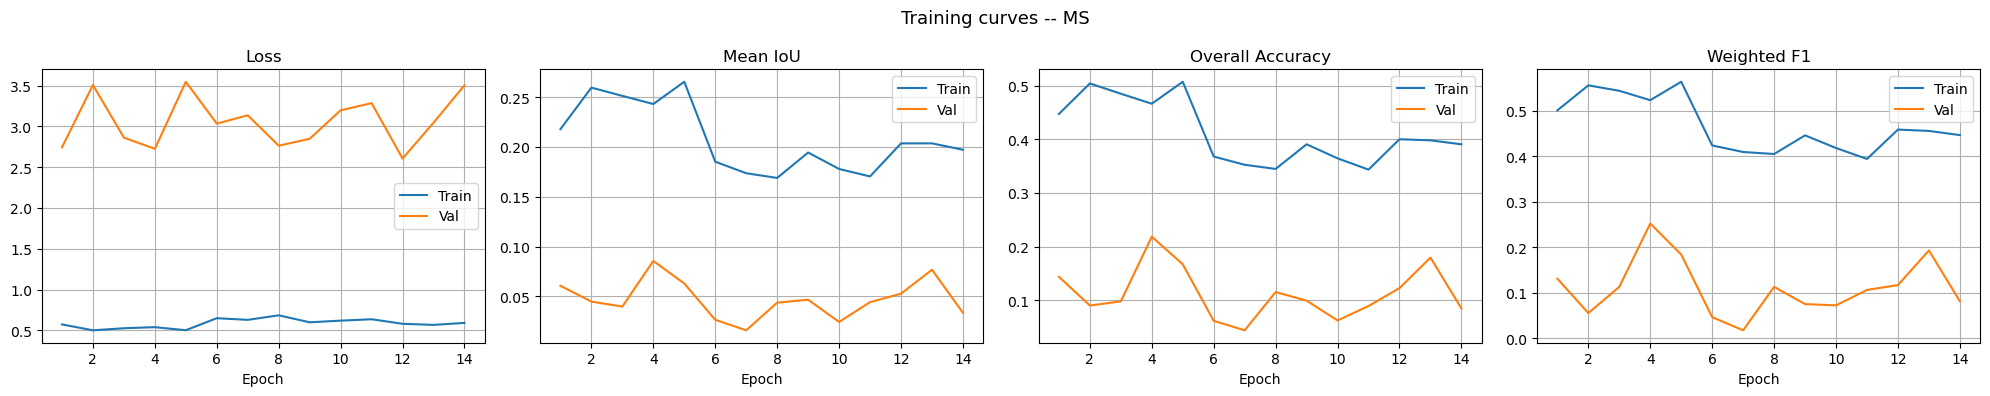

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, tc, vc, title in zip(
    axes,
    ['train_loss', 'train_miou', 'train_oa', 'train_f1'],
    ['val_loss',   'val_miou',   'val_oa',   'val_f1'],
    ['Loss', 'Mean IoU', 'Overall Accuracy', 'Weighted F1']
):
    ax.plot(history_df['epoch'], history_df[tc], label='Train')
    ax.plot(history_df['epoch'], history_df[vc], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)

plt.suptitle(f'Training curves -- {MODALITY.upper()}', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'training_curves_{MODALITY}.png', dpi=150)
plt.show()

## 12. Test set evaluation

Loaded best model from E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\ms\best_model_ms.pth
  [Test] 200/1269 | loss=0.6970
  [Test] 400/1269 | loss=0.5605
  [Test] 600/1269 | loss=8.6795
  [Test] 800/1269 | loss=8.1627
  [Test] 1000/1269 | loss=3.4965
  [Test] 1200/1269 | loss=1.7952
  [Test] 1269/1269 | loss=2.4211

RESULTS -- MS -- TEST SET
  Overall Accuracy   : 0.2208
  Mean IoU           : 0.0679
  Weighted F1        : 0.3159
  Weighted Precision : 0.7023
  Weighted Recall    : 0.2208

  Class                     IoU       PA       UA       F1
  -------------------------------------------------------
  Maize                  0.0960   0.2762   0.1283   0.1752
  Maize+Pumpkin          0.0341   0.3741   0.0362   0.0660
  Beans+Maize            0.0000   0.0000   0.0000   0.0000
  Cassava+Maize          0.0001   0.0055   0.0001   0.0002 *
  Grass                  0.2520   0.2584   0.9106   0.4026
  Mixed                  0.0249   0.0284   0.1697   0.0487
  * low-confidence class

Saved

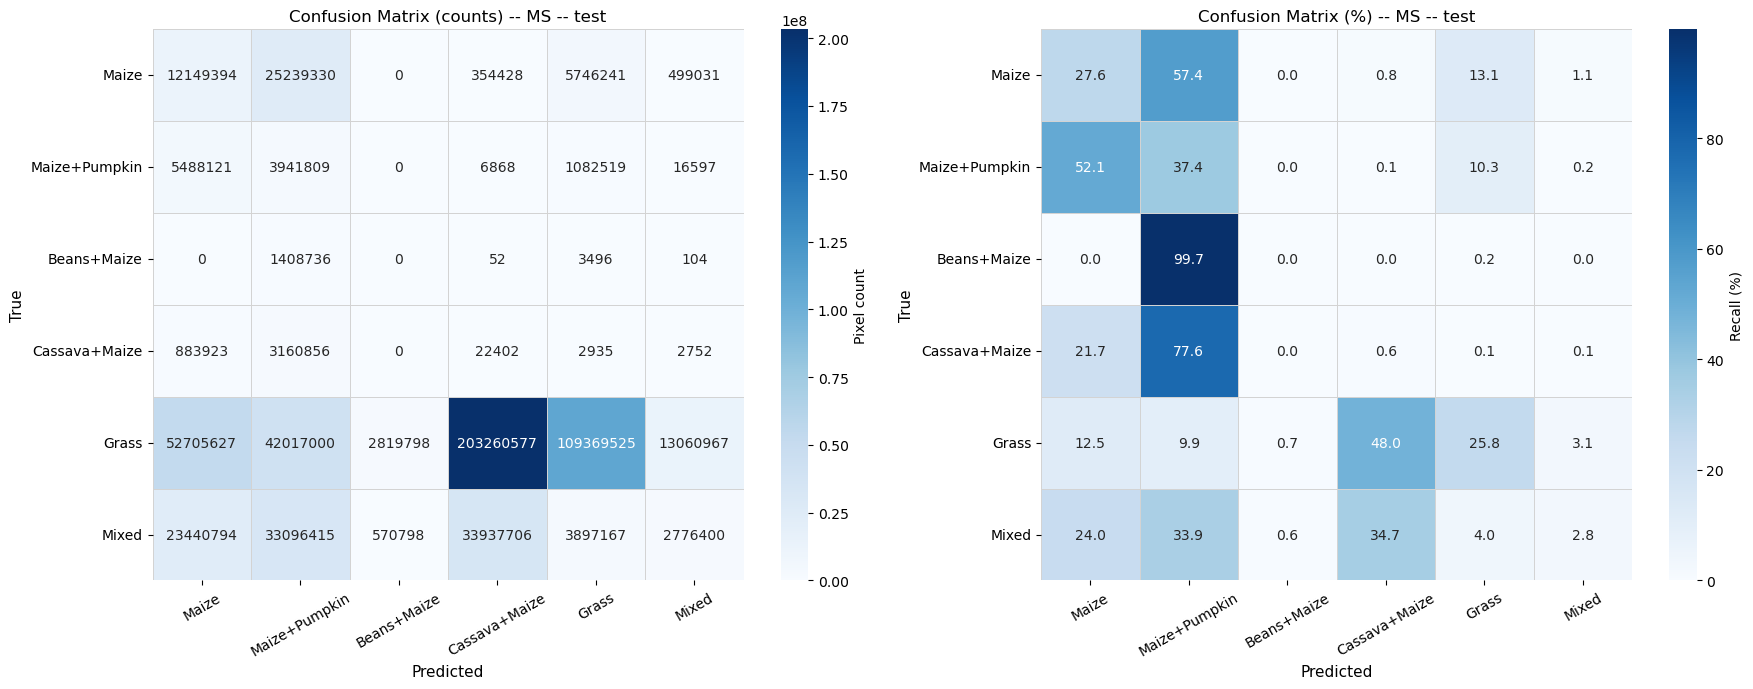

Results saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\ms\test_results_ms.csv


In [15]:
model.load_state_dict(
    torch.load(best_model_path, map_location=DEVICE)
)
print(f"Loaded best model from {best_model_path}", flush=True)

test_metrics = evaluate(
    model, test_dl, criterion_val, DEVICE, 'Test'
)

print_full_report(test_metrics, CLASS_NAMES, MODALITY, 'test')

plot_confusion_matrix(
    test_metrics['conf_matrix'], CLASS_NAMES,
    MODALITY, 'test',
    save_path=OUTPUT_DIR / f'confusion_matrix_{MODALITY}.png',
)

results_rows = []
for i, name in enumerate(CLASS_NAMES):
    results_rows.append({
        'class':     name,
        'iou':       test_metrics['iou_per_class'][i],
        'PA':        test_metrics['recall_per_class'][i],
        'UA':        test_metrics['precision_per_class'][i],
        'f1':        test_metrics['f1_per_class'][i],
    })
results_rows.append({
    'class': 'Weighted Average',
    'iou':   test_metrics['miou'],
    'PA':    test_metrics['weighted_recall'],
    'UA':    test_metrics['weighted_precision'],
    'f1':    test_metrics['weighted_f1'],
})
results_rows.append({
    'class': 'Overall Accuracy',
    'iou':   test_metrics['overall_acc'],
    'PA': '', 'UA': '', 'f1': '',
})
results_df = pd.DataFrame(results_rows)
results_df.to_csv(
    OUTPUT_DIR / f'test_results_{MODALITY}.csv', index=False
)
print(f"Results saved -> "
      f"{OUTPUT_DIR / f'test_results_{MODALITY}.csv'}")

## 13. PA / UA diagnostic

In [16]:
conf_matrix = test_metrics['conf_matrix']

print(f"{'='*75}")
print(f"PRODUCER / USER ACCURACY -- {MODALITY.upper()} -- TEST")
print(f"{'='*75}")
print(
    f"{'Class':20s}  {'PA':>8}  {'UA':>8}  "
    f"{'F1':>8}  {'IoU':>8}  {'True px':>12}  Diagnosis"
)
print("-" * 75)

diag_rows = []
for i, name in enumerate(CLASS_NAMES):
    tp      = conf_matrix[i, i]
    row_sum = conf_matrix[i, :].sum()
    col_sum = conf_matrix[:, i].sum()
    fp = col_sum - tp
    fn = row_sum - tp
    pa  = tp / (row_sum + 1e-6)
    ua  = tp / (col_sum + 1e-6)
    f1  = 2 * pa * ua / (pa + ua + 1e-6)
    iou = tp / (tp + fp + fn + 1e-6)

    if row_sum == 0:
        diag = "NO TRUE PIXELS"
    elif tp == 0:
        diag = "NEVER PREDICTED"
    elif pa < 0.10:
        fn_row = conf_matrix[i, :].copy()
        fn_row[i] = 0
        diag = f"LOW PA -> '{CLASS_NAMES[fn_row.argmax()]}'"
    elif ua < 0.10:
        fp_col = conf_matrix[:, i].copy()
        fp_col[i] = 0
        diag = f"LOW UA -> '{CLASS_NAMES[fp_col.argmax()]}' misclassified here"
    else:
        diag = "OK"

    print(
        f"  {name:20s}  {pa:>8.4f}  {ua:>8.4f}  "
        f"{f1:>8.4f}  {iou:>8.4f}  "
        f"{row_sum:>12,}  {diag}"
    )
    diag_rows.append({
        'Class': name, 'PA': round(pa, 4), 'UA': round(ua, 4),
        'F1': round(f1, 4), 'IoU': round(iou, 4),
        'True_px': int(row_sum), 'Diagnosis': diag
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(
    OUTPUT_DIR / f'pa_ua_diagnostic_{MODALITY}.csv', index=False
)
display(diag_df)

print("\nConfusion breakdown:")
for i, name in enumerate(CLASS_NAMES):
    row_sum = conf_matrix[i, :].sum()
    if row_sum == 0:
        continue
    row_pct = conf_matrix[i, :] / (row_sum + 1e-6) * 100
    print(f"\n  True: {name} ({row_sum:,} px)")
    for j, cname in enumerate(CLASS_NAMES):
        if row_pct[j] > 1.0:
            marker = " <-- correct" if i == j else ""
            print(
                f"    -> {cname:20s} : {row_pct[j]:5.1f}%{marker}"
            )

PRODUCER / USER ACCURACY -- MS -- TEST
Class                       PA        UA        F1       IoU       True px  Diagnosis
---------------------------------------------------------------------------
  Maize                   0.2762    0.1283    0.1752    0.0960    43,988,424  OK
  Maize+Pumpkin           0.3741    0.0362    0.0660    0.0341    10,535,914  LOW UA -> 'Grass' misclassified here
  Beans+Maize             0.0000    0.0000    0.0000    0.0000     1,412,388  NEVER PREDICTED
  Cassava+Maize           0.0055    0.0001    0.0002    0.0001     4,072,868  LOW PA -> 'Maize+Pumpkin'
  Grass                   0.2584    0.9106    0.4026    0.2520   423,233,494  OK
  Mixed                   0.0284    0.1697    0.0487    0.0249    97,719,280  LOW PA -> 'Cassava+Maize'


,Class,PA,UA,F1,IoU,True_px,Diagnosis
0,Maize,0.2762,0.1283,0.1752,0.0960,43988424,OK
1,Maize+Pumpkin,0.3741,0.0362,0.0660,0.0341,10535914,LOW UA -> 'Grass' misclassified here
2,Beans+Maize,0.0000,0.0000,0.0000,0.0000,1412388,NEVER PREDICTED
3,Cassava+Maize,0.0055,0.0001,0.0002,0.0001,4072868,LOW PA -> 'Maize+Pumpkin'
4,Grass,0.2584,0.9106,0.4026,0.2520,423233494,OK
5,Mixed,0.0284,0.1697,0.0487,0.0249,97719280,LOW PA -> 'Cassava+Maize'



Confusion breakdown:

  True: Maize (43,988,424 px)
    -> Maize                :  27.6% <-- correct
    -> Maize+Pumpkin        :  57.4%
    -> Grass                :  13.1%
    -> Mixed                :   1.1%

  True: Maize+Pumpkin (10,535,914 px)
    -> Maize                :  52.1%
    -> Maize+Pumpkin        :  37.4% <-- correct
    -> Grass                :  10.3%

  True: Beans+Maize (1,412,388 px)
    -> Maize+Pumpkin        :  99.7%

  True: Cassava+Maize (4,072,868 px)
    -> Maize                :  21.7%
    -> Maize+Pumpkin        :  77.6%

  True: Grass (423,233,494 px)
    -> Maize                :  12.5%
    -> Maize+Pumpkin        :   9.9%
    -> Cassava+Maize        :  48.0%
    -> Grass                :  25.8% <-- correct
    -> Mixed                :   3.1%

  True: Mixed (97,719,280 px)
    -> Maize                :  24.0%
    -> Maize+Pumpkin        :  33.9%
    -> Cassava+Maize        :  34.7%
    -> Grass                :   4.0%
    -> Mixed                :   

## 14. Visualisation — prediction vs ground truth vs image

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\Models\ms\viz_test_ms.png


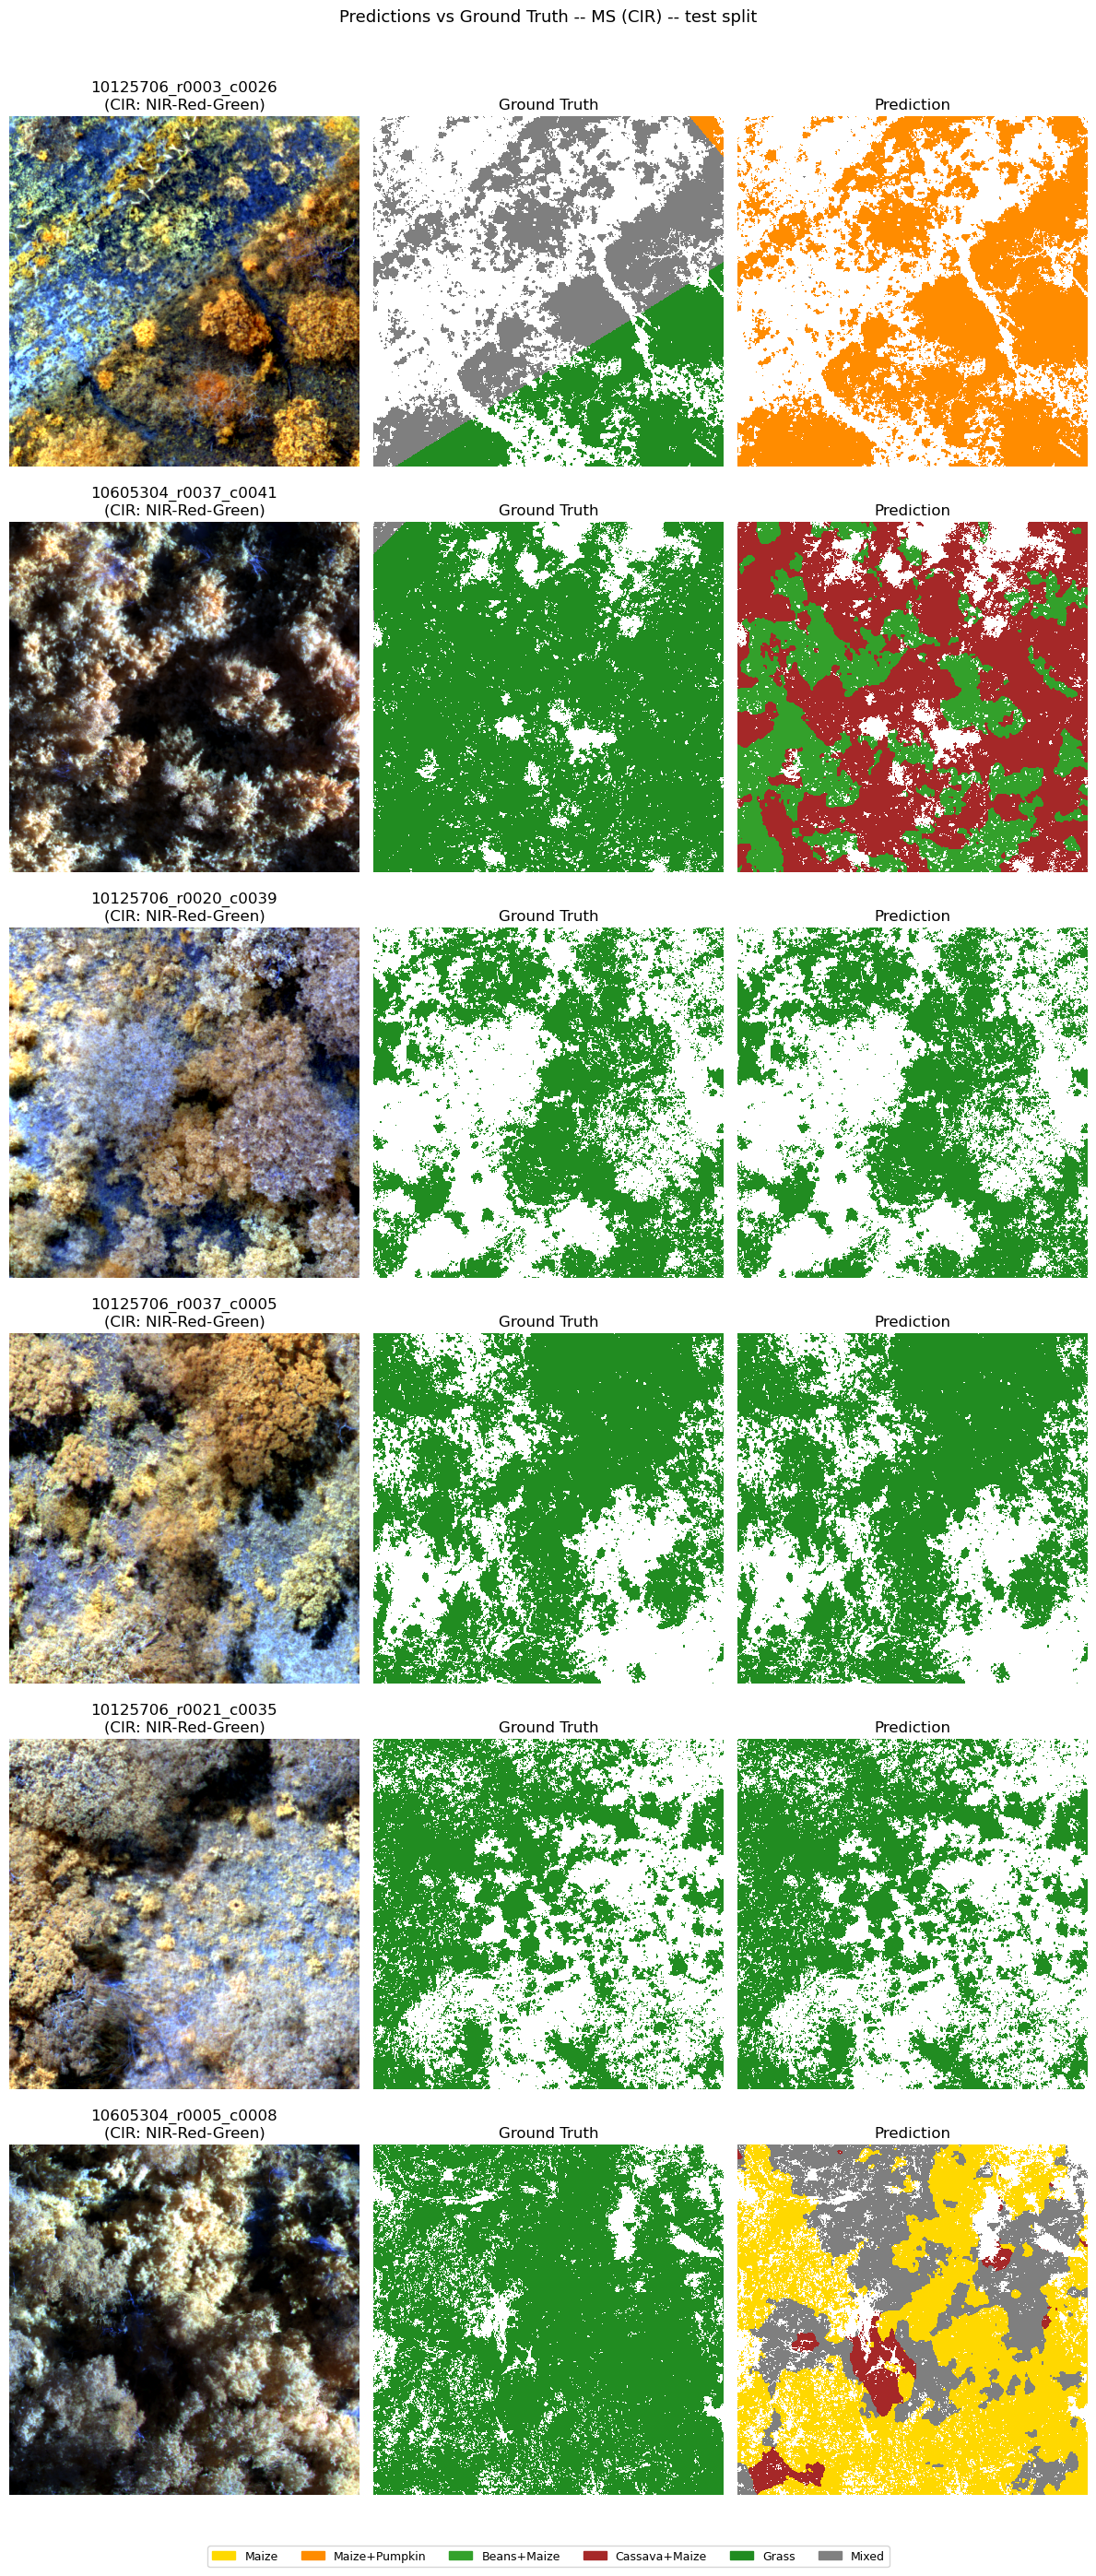

In [17]:
@torch.no_grad()
def visualise_predictions(model, img_dir, lbl_dir, split,
                          mean, std, device,
                          n_samples=6, save_path=None):
    model.eval()
    tile_dir = Path(img_dir) / split
    lbl_dir_ = Path(lbl_dir) / split
    tiles    = sorted(tile_dir.glob('*.tif'))
    selected = random.sample(tiles, min(n_samples, len(tiles)))

    fig, axes = plt.subplots(
        len(selected), 3, figsize=(12, 4.5 * len(selected))
    )
    if len(selected) == 1:
        axes = [axes]

    for row_idx, tile_path in enumerate(selected):
        with rasterio.open(tile_path) as src:
            img_raw = src.read().astype(np.float32)

        img_norm = img_raw.copy()
        for c in range(img_norm.shape[0]):
            img_norm[c] = (
                (img_norm[c] - mean[c]) / (std[c] + 1e-6)
            )

        tensor    = torch.tensor(img_norm).unsqueeze(0).to(device)
        output    = model(pixel_values=tensor)
        logits_up = nn.functional.interpolate(
            output.logits, size=(TILE_SIZE, TILE_SIZE),
            mode='bilinear', align_corners=False
        )
        pred = logits_up.argmax(dim=1).squeeze(0).cpu().numpy()

        with rasterio.open(lbl_dir_ / tile_path.name) as src:
            lbl = src.read(1).astype(np.float32)

        # Display as false colour: MS Red = R, MS Green = G, NIR = B
        # This gives a CIR-like false colour image
        r   = img_raw[0]   # MS Red
        g   = img_raw[1]   # MS Green
        nir = img_raw[2]   # NIR
        cir = np.stack([nir, r, g], axis=-1)   # CIR composite
        p2  = np.percentile(cir,  2, axis=(0, 1))
        p98 = np.percentile(cir, 98, axis=(0, 1))
        cir = np.clip((cir - p2) / (p98 - p2 + 1e-6), 0, 1)

        lbl_disp  = np.ma.masked_where(lbl == IGNORE_INDEX, lbl)
        pred_disp = np.ma.masked_where(lbl == IGNORE_INDEX, pred)

        ax_img, ax_gt, ax_pred = axes[row_idx]

        ax_img.imshow(cir)
        ax_img.set_title(
            f"{tile_path.stem}\n(CIR: NIR-Red-Green)"
        )
        ax_img.axis('off')

        ax_gt.imshow(
            lbl_disp, cmap=CMAP, vmin=0,
            vmax=NUM_CLASSES - 1, interpolation='nearest'
        )
        ax_gt.set_title('Ground Truth')
        ax_gt.axis('off')

        ax_pred.imshow(
            pred_disp, cmap=CMAP, vmin=0,
            vmax=NUM_CLASSES - 1, interpolation='nearest'
        )
        ax_pred.set_title('Prediction')
        ax_pred.axis('off')

    fig.legend(
        handles=make_legend_patches(),
        loc='lower center', ncol=NUM_CLASSES,
        bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=True,
    )
    plt.suptitle(
        f'Predictions vs Ground Truth -- MS (CIR) -- {split} split',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved -> {save_path}")
    plt.show()


visualise_predictions(
    model, IMG_DIR, LBL_DIR, split='test',
    mean=MEAN, std=STD, device=DEVICE, n_samples=6,
    save_path=OUTPUT_DIR / f'viz_test_{MODALITY}.png'
)